In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler

# Darts functions
from darts.timeseries import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TSMixerModel

/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv('bike data.csv')
data['ds'] = pd.to_datetime(data['Date']) + pd.to_timedelta(data['Hour'], unit='h')
data.rename(columns={'Total Users': 'y'}, inplace=True)
data.drop(columns=['Date', 'Season', 'Hour', 'Casual Users', 'Registered Users', 'Day of the Week', 'Temperature Feels F'], inplace=True)
data.set_index('ds', inplace=True)
df = data.asfreq('h')
df.ffill(inplace=True)

df.head()

,Holiday,Working Day,Weather Type,Temperature F,Humidity,Wind Speed,y
ds,,,,,,,
2011-01-01 00:00:00,0.0,0.0,1.0,36.6,81.0,0.0,16.0
2011-01-01 01:00:00,0.0,0.0,1.0,34.9,80.0,0.0,40.0
2011-01-01 02:00:00,0.0,0.0,1.0,34.9,80.0,0.0,32.0
2011-01-01 03:00:00,0.0,0.0,1.0,36.6,75.0,0.0,13.0
2011-01-01 04:00:00,0.0,0.0,1.0,36.6,75.0,0.0,1.0


Exploratory Data Analysis

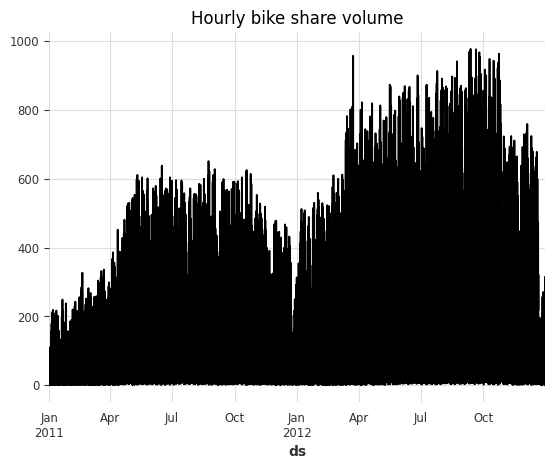

In [4]:
df['y'].plot(title = 'Hourly bike share volume')
plt.show()

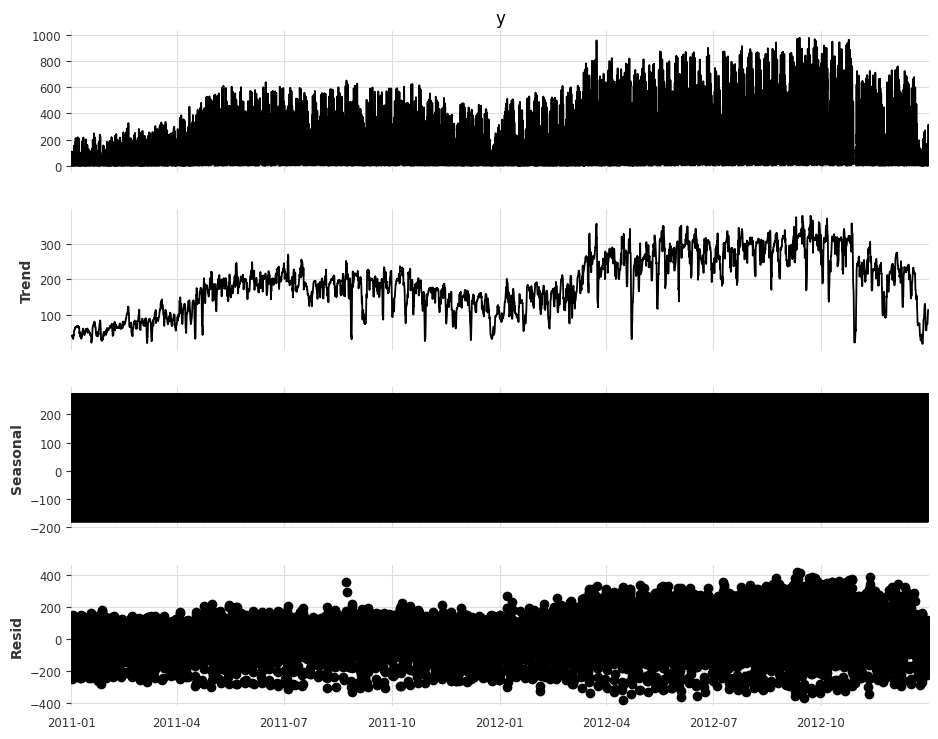

In [5]:
decomposition = seasonal_decompose(df['y'],
                                   model = 'add',
                                   period = 24)

fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

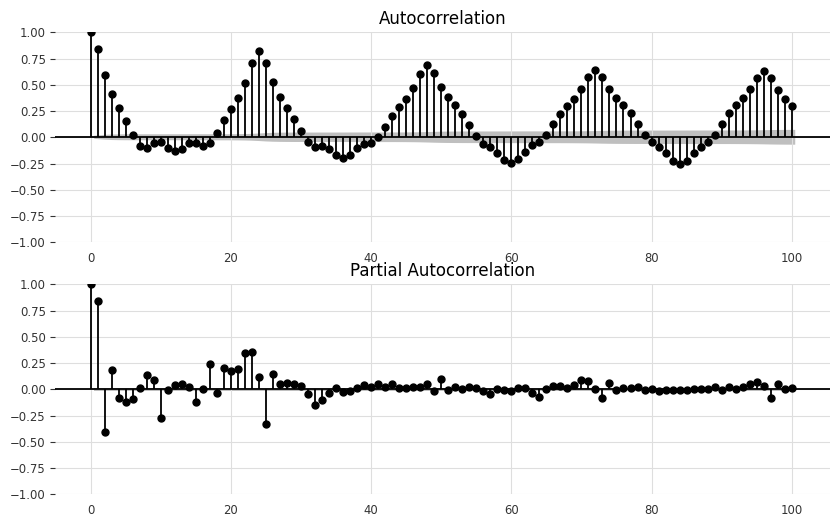

In [7]:
fig, ax = plt.subplots(2, 1, figsize = (10,6))
plot_acf(df['y'], lags=100, ax = ax[0])
plot_pacf(df['y'], lags=100, ax = ax[1])

plt.show()

Data Preparation

In [8]:
# Function to encode the year as a normalized value
def encode_year(idx):
  return (idx.year - 2000) / 50

# Set up the add_encoders dictionary to specify how different time-related encoders and transformers should be applied
add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
}

In [10]:
# Prepare a TimeSeries object from the dataframe with Hourly frequency
series = TimeSeries.from_dataframe(df,
                                   value_cols = 'y',
                                   freq = 'h')
series

<TimeSeries (DataArray) (ds: 17544, component: 1, sample: 1)> Size: 140kB
array([[[16.]],

       [[40.]],

       [[32.]],

       ...,

       [[90.]],

       [[61.]],

       [[49.]]])
Coordinates:
  * ds         (ds) datetime64[ns] 140kB 2011-01-01 ... 2012-12-31T23:00:00
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None

In [ ]:
X_past = df.iloc[:, :-1]
past_covariates = TimeSeries.from_dataframe(X_past, freq = 'h')

In [12]:
scaler_y = Scaler()
scaler_covariates = Scaler()

y_transformed = scaler_y.fit_transform(series)

past_covariates_transformed = scaler_covariates.fit_transform(past_covariates)

TSMixer model

In [13]:
forecast_horizon = 24

In [14]:
model = TSMixerModel(
    input_chunk_length=120,
    output_chunk_length=forecast_horizon,
    use_reversible_instance_norm=True,
    ff_size=5,
    num_blocks=4,
    hidden_size=20,
    add_encoders = add_encoders,
    n_epochs=10,
    pl_trainer_kwargs={"accelerator": "cpu"},
   # pl_trainer_kwargs= {'accelerator': 'gpu','devices': [0]}
)

In [15]:
model.fit(y_transformed, past_covariates = past_covariates_transformed)

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | criterion             | MSELoss          | 0      | train
1  | train_criterion       | MSELoss          | 0      | train
2  | val_criterion         | MSELoss          | 0      | train
3  | train_metrics         | MetricCollection | 0      | train
4  | val_metrics           | MetricCollection | 0      | train
5  | rin                   | RINorm           | 2      | train
6  | fc_hist               | Linear           | 2.9 K  | train
7  | feature_mixing_hist   | _FeatureMixing   | 1.8 K  | train
8  | feature_mixing_future | _FeatureMixing   | 1.5 K

Epoch 9: 100%|██████████| 544/544 [00:06<00:00, 89.43it/s, train_loss=0.00313]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 544/544 [00:06<00:00, 89.41it/s, train_loss=0.00313]


TSMixerModel(output_chunk_shift=0, hidden_size=20, ff_size=5, num_blocks=4, activation=ReLU, dropout=0.1, norm_type=LayerNorm, normalize_before=False, use_static_covariates=True, input_chunk_length=120, output_chunk_length=24, use_reversible_instance_norm=True, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7f87245f0540>], 'future': [<function encode_year at 0x7f87245f0540>]}, 'transformer': Scaler, 'tz': 'CET'}, n_epochs=10, pl_trainer_kwargs={'accelerator': 'cpu'})

Cross-validation

In [16]:
# Perform cross-validation with rolling forecast using the TFT model
cv = model.historical_forecasts(
        series=y_transformed,
        past_covariates = past_covariates_transformed,
        start = len(df) - 120,
        forecast_horizon=forecast_horizon,
        stride=forecast_horizon,
        retrain=True,
        last_points_only=False)

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | criterion             | MSELoss          | 0      | train
1  | train_criterion       | MSELoss          | 0      | train
2  | val_criterion         | MSELoss          | 0      | train
3  | train_metrics         | MetricCollection | 0      | train
4  | val_metrics           | MetricCollection | 0      | train
5  | rin                   | RINorm           | 2      | train
6  | fc_hist        

Epoch 9: 100%|██████████| 541/541 [00:05<00:00, 90.85it/s, train_loss=0.000565]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 541/541 [00:05<00:00, 90.84it/s, train_loss=0.000565]


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | criterion             | MSELoss          | 0      | train
1  | train_criterion       | MSELoss          | 0      | train
2  | val_criterion         | MSELoss          | 0      | train
3  | train_metrics         | MetricCollection | 0      | t

...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | criterion             | MSELoss          | 0      | train
1  | train_criterion       | MSELoss          | 0      | train
2  | val_criterion         | MSELoss          | 0      | train
3  | train_metrics         | MetricCollection | 0      | t

Epoch 9: 100%|██████████| 544/544 [00:06<00:00, 90.11it/s, train_loss=0.000788]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 544/544 [00:06<00:00, 90.10it/s, train_loss=0.000788]


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [18]:
rmse_cv = []

for i in range(len(cv)):
    predictions = TimeSeries.pd_series(scaler_y.inverse_transform(cv[i]))

    start = predictions.index.min()
    end = predictions.index.max()
    actuals = df.y[start:end]

    error_cv = np.sqrt(mean_squared_error(actuals, predictions))
    rmse_cv.append(error_cv)

print(f"The mean CV error is {np.mean(rmse_cv)}")
print(f"Here is the list of errors {rmse_cv}")

The mean CV error is 58.61394192458529
Here is the list of errors [64.69319332092549, 79.65698319464303, 40.80929738242105, 34.7231609688827, 73.18707475605414]


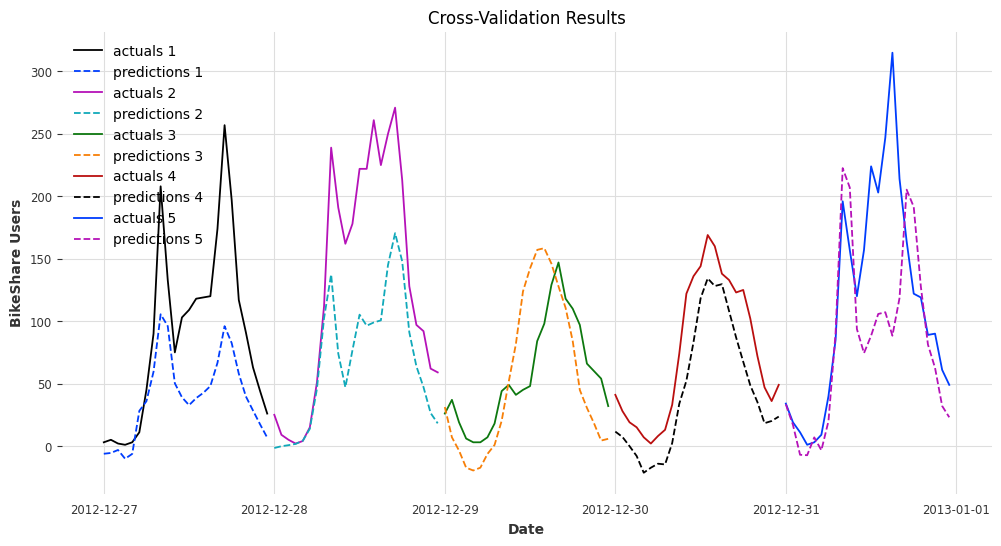

In [19]:
fig, ax = plt.subplots(figsize = (12,6))

for i in range(len(cv)):
  predictions = TimeSeries.pd_series(scaler_y.inverse_transform(cv[i]))

  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.loc[start:end, 'y']

  ax.plot(actuals, label = f"actuals {i+1}")
  ax.plot(predictions, label = f"predictions {i+1}", linestyle = 'dashed')

ax.legend()
ax.set_title("Cross-Validation Results")
ax.set_xlabel("Date")
ax.set_ylabel("BikeShare Users")

plt.show()

Parameter Tuning

In [20]:
param_grid = {
    'input_chunk_length': [72, 96, 120],
    'n_epochs': [5, 10],
    'ff_size': [5, 10, 15],
    'num_blocks': [1, 2, 3],
    'hidden_size': [5, 10]
}

In [21]:
fixed_params = {
    'output_chunk_length': forecast_horizon,
    'use_reversible_instance_norm': True,
    'random_state': 42,
    'pl_trainer_kwargs': {"accelerator": "cpu"},
}

In [22]:
n_iter = 5

param_list = list(ParameterSampler(param_grid,
                                   n_iter=n_iter,
                                   random_state=42))

In [24]:
for params in param_list:
  params.update(fixed_params)

In [25]:
total_rmse = []

for params in param_list:

    model = TSMixerModel(**params)

    cv = model.historical_forecasts(series=y_transformed,
                                    past_covariates = past_covariates_transformed,
                                    start = len(df) - 240,
                                    forecast_horizon=forecast_horizon,
                                    stride=forecast_horizon,
                                    last_points_only=False,
                                    retrain=True,
                                    enable_optimization=False,
                                    verbose=False)

    rmse_cv = []

    for i in range(len(cv)):

        predictions = TimeSeries.pd_series(scaler_y.inverse_transform(cv[i]))

        start = predictions.index.min()
        end = predictions.index.max()
        actuals = df.loc[start:end, 'y']

        rmse = np.sqrt(mean_squared_error(actuals, predictions))
        rmse_cv.append(rmse)

    mean_rmse = np.mean(rmse_cv)
    total_rmse.append(mean_rmse)
    print(f"The RMSE was {mean_rmse} with params {params}")


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | train
5 | rin                 | RINorm           | 2      | train
6 | fc_hist             | Linear           | 1.8 K  | train
7 | feature_mixing_hist | _FeatureMixing   | 480    | train
8 | conditional_mixer   | ModuleList       | 3.8 K  | train
9 | fc_out             

Epoch 9: 100%|██████████| 538/538 [00:03<00:00, 137.96it/s, train_loss=0.00917]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 538/538 [00:03<00:00, 137.93it/s, train_loss=0.00917]


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | train
5 | rin                 | RINorm           | 2      | train
6 | fc_hist             | Linear           | 1.8 K  | train
7 | feature_mixing_hist | 

...

Epoch 4: 100%|██████████| 544/544 [00:04<00:00, 129.28it/s, train_loss=0.00694]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 544/544 [00:04<00:00, 129.25it/s, train_loss=0.00694]


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


The RMSE was 79.00415726274728 with params {'num_blocks': 3, 'n_epochs': 5, 'input_chunk_length': 96, 'hidden_size': 10, 'ff_size': 10, 'output_chunk_length': 24, 'use_reversible_instance_norm': True, 'random_state': 42, 'pl_trainer_kwargs': {'accelerator': 'cpu'}}


In [31]:
rmse

66.55087887525828

In [38]:
results_df = pd.DataFrame(param_list)
results_df['rmse'] = total_rmse
best_rmse = min(total_rmse)
best_params = results_df.query('rmse == @best_rmse')

Predictions

In [41]:
best_params_dict = best_params.iloc[:,:-2].squeeze().to_dict()

In [42]:
for key, value in best_params_dict.items():
  try:
    best_params_dict[key] = int(value)
  except ValueError:
    pass

best_params_dict

{'num_blocks': 2,
 'n_epochs': 10,
 'input_chunk_length': 72,
 'hidden_size': 5,
 'ff_size': 5,
 'output_chunk_length': 24,
 'use_reversible_instance_norm': 1,
 'random_state': 42}

In [43]:
tuned_model = TSMixerModel(**best_params_dict)
tuned_model.fit(y_transformed,
                past_covariates = past_covariates_transformed)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | train
5 | rin                 | RINorm           | 2     

Epoch 9: 100%|██████████| 546/546 [00:03<00:00, 160.03it/s, train_loss=0.00462]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 546/546 [00:03<00:00, 159.98it/s, train_loss=0.00462]


TSMixerModel(output_chunk_shift=0, hidden_size=5, ff_size=5, num_blocks=2, activation=ReLU, dropout=0.1, norm_type=LayerNorm, normalize_before=False, use_static_covariates=True, n_epochs=10, input_chunk_length=72, output_chunk_length=24, use_reversible_instance_norm=1, random_state=42)

In [44]:
forecast = tuned_model.predict(n = forecast_horizon,
                               series = y_transformed,
                               past_covariates = past_covariates_transformed)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 246.83it/s]


In [45]:
forecast = TimeSeries.pd_series(
    scaler_y.inverse_transform(forecast)).rename("TS Mixer")

forecast

ds
2013-01-01 00:00:00     33.513198
2013-01-01 01:00:00     29.572990
2013-01-01 02:00:00      7.317061
2013-01-01 03:00:00     -7.674669
2013-01-01 04:00:00    -26.958623
2013-01-01 05:00:00     -3.038095
2013-01-01 06:00:00     16.342235
2013-01-01 07:00:00     44.791329
2013-01-01 08:00:00    111.327827
2013-01-01 09:00:00    119.799985
2013-01-01 10:00:00    101.309921
2013-01-01 11:00:00     99.916863
2013-01-01 12:00:00    126.307666
2013-01-01 13:00:00    130.679009
2013-01-01 14:00:00    188.622189
2013-01-01 15:00:00    188.269381
2013-01-01 16:00:00    149.561207
2013-01-01 17:00:00    152.464562
2013-01-01 18:00:00    179.163160
2013-01-01 19:00:00    174.463211
2013-01-01 20:00:00    119.242064
2013-01-01 21:00:00     82.333895
2013-01-01 22:00:00     61.191690
2013-01-01 23:00:00     16.431960
Freq: h, Name: TS Mixer, dtype: float64

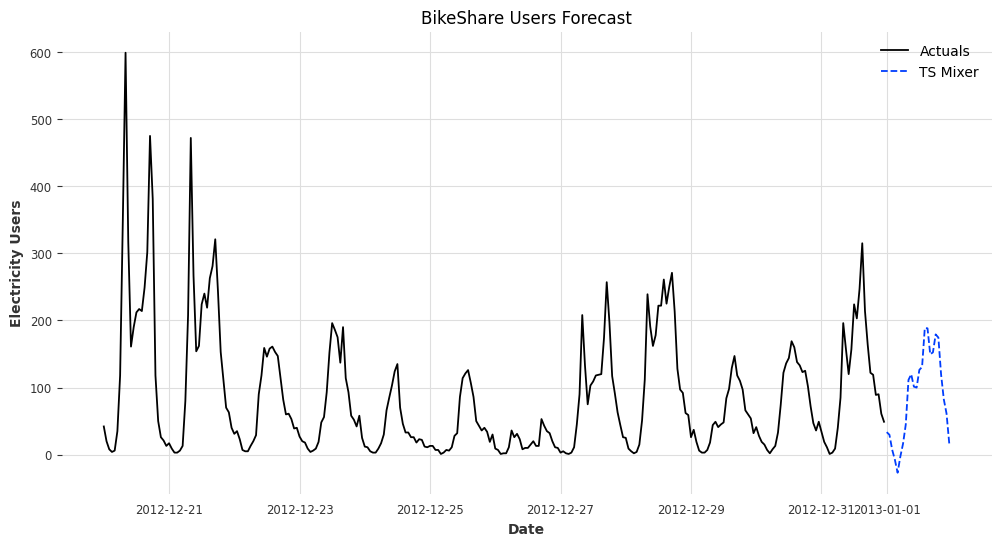

In [46]:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(df['y']['2012-12-20':], label = "Actuals")
ax.plot(forecast, label = 'TS Mixer', linestyle = 'dashed')

ax.legend()
ax.set_title("BikeShare Users Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Electricity Users")
plt.show()